# VAE Source Comparison

Notebook-first workflow for comparing VAE candidate sources before moving into POMDP work.

Default flow:
1. Load or generate matched candidate pools for curated v4, random v1, and mixed 70/30 VAE runs.
2. Summarize safety, outcome, spawn-region, and hit-count statistics.
3. Plot source-to-source candidate-pool differences.
4. Optionally run matched Monte Carlo full-state candidate evaluation for all sources.

Use this notebook to decide which VAE source should be frozen as the GenAI candidate source for the next POMDP phase.


## Imports


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve repo root when this notebook is launched from either repo root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "convoy_sim").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from convoy_sim.profile_generation_viz import FIXED_X_LIMITS, apply_limits, combined_limits, simple_ship_polygons, style_ax
from convoy_sim.profile_outcome_audit import OutcomeAuditConfig
from convoy_sim.workflows import write_json
from experiments.audit_attack_profile_dataset import load_dataset_records
from experiments.evaluate_attack_candidate_pool import evaluate_candidate_pool
from experiments.generate_vae_candidate_pool import build_vae_candidate_records, render_vae_candidate_jsonl
from scenarios.convoy_profiles import get_convoy_layout_profile

PROJECT_ROOT


PosixPath('/Users/matthewplambeck/Desktop/Convoy Layout Project')

## Config


In [2]:
CONVOY_PROFILE = "convoy_layout_1"
CHECKPOINT_NAME = "model_best.pt"

SOURCE_CONFIGS = [
    {
        "source_id": "curated_v4",
        "label": "Curated v4",
        "run_dir": Path("results/runs/vae/20260511_005053_v4_notebook"),
        "train_path": Path("data/attack_profiles/synthetic/train_random_tactical_v4_45k.jsonl"),
        "candidate_path": Path("data/attack_profiles/vae_candidates/curated_v4_hit_candidates.jsonl"),
        "start_index": 1,
    },
    {
        "source_id": "random_v1",
        "label": "Random v1",
        "run_dir": Path("results/runs/vae/20260511_161735_random_v1_notebook"),
        "train_path": Path("data/attack_profiles/synthetic/train_random_profile_v1_45k.jsonl"),
        "candidate_path": Path("data/attack_profiles/vae_candidates/random_v1_hit_candidates.jsonl"),
        "start_index": 1,
    },
    {
        "source_id": "mixed_70_30",
        "label": "Mixed 70/30",
        "run_dir": Path("results/runs/vae/20260511_195317_mixed_curated70_random30_v1_notebook"),
        "train_path": Path("data/attack_profiles/synthetic/train_mixed_curated70_random30_45k.jsonl"),
        "candidate_path": Path("data/attack_profiles/vae_candidates/mixed_curated70_random30_hit_candidates.jsonl"),
        "start_index": 1,
    },
]

# Candidate-pool generation.
RUN_CANDIDATE_GENERATION = True
FORCE_REGENERATE_CANDIDATES = False
SAMPLE_COUNT = 5_000
KEEP_COUNT = 1_000
SEED = 1945
DEVICE = "cpu"  # cpu is slower but most reliable; change to "mps" if desired.
SAMPLING_METHOD = "latent_bank"
LATENT_NOISE_SCALE = 0.10
MIN_CLEARANCE_M = 250.0
ACCEPTED_OUTCOMES = ("credible_hit_threat",)
DYNAMIC_AUDIT_T_MAX_S = 600.0
DYNAMIC_AUDIT_DT_S = 0.5

# Optional full-state Monte Carlo evaluation.
RUN_MONTE_CARLO_EVALUATION = True
MAX_EVAL_PROFILES = 100
TOP_K = 25
EVAL_SEEDS = [1942, 1943, 1944]
N_TRIALS_PER_SEED = 10
EVAL_T_MAX = 400.0
OBJECTIVE_PRESET = "balanced_default"

OUTPUT_DIR = PROJECT_ROOT / "results" / "diag" / "vae_source_comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Helpers


In [3]:
def summary_path_for(candidate_path: Path) -> Path:
    return candidate_path.with_suffix(candidate_path.suffix + ".summary.json")


def load_candidate_records(path: Path) -> list[dict[str, Any]]:
    records: list[dict[str, Any]] = []
    with path.open("r", encoding="utf-8") as handle:
        for line in handle:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def candidate_records_to_df(records: list[dict[str, Any]], *, source_id: str, source_label: str) -> pd.DataFrame:
    rows = []
    for record in records:
        profile = dict(record["profile"])
        audit = dict(record.get("audit", {}))
        intent = dict(record.get("intent", {}))
        outcome = dict(record.get("outcome", {}))
        rows.append(
            {
                "source_id": source_id,
                "source_label": source_label,
                "profile_id": str(profile.get("profile_id", "")),
                "u_pos": list(profile.get("u_pos", [np.nan, np.nan])),
                "u_pos_x": float(profile.get("u_pos", [np.nan, np.nan])[0]),
                "u_pos_y": float(profile.get("u_pos", [np.nan, np.nan])[1]),
                "spawn_region": str(intent.get("spawn_region", audit.get("spawn_region", ""))),
                "approach_side": str(intent.get("approach_side", audit.get("approach_side", ""))),
                "inside_convoy_envelope": bool(intent.get("inside_convoy_envelope", audit.get("inside_convoy_envelope", False))),
                "suggested_label": str(audit.get("suggested_label", "")),
                "actual_outcome_label": str(audit.get("actual_outcome_label", outcome.get("actual_outcome_label", ""))),
                "clearance_m": float(audit.get("clearance_m", np.nan)),
                "n_hits": int(audit.get("n_hits", outcome.get("n_hits", 0))),
                "unique_ships_hit": int(audit.get("unique_ships_hit", outcome.get("unique_ships_hit", 0))),
                "closest_any_ship_distance_m": float(audit.get("closest_any_ship_distance_m", np.nan)),
                "closest_any_ship_id": str(audit.get("closest_any_ship_id", outcome.get("closest_any_ship_id", ""))),
            }
        )
    return pd.DataFrame(rows)


def source_summary_row(source_cfg: dict[str, Any], summary: dict[str, Any], candidate_df: pd.DataFrame) -> dict[str, Any]:
    pre = dict(summary.get("pre_filter_audit", {}))
    return {
        "source_id": source_cfg["source_id"],
        "source_label": source_cfg["label"],
        "sample_count": int(summary.get("sample_count", 0)),
        "accepted_count": int(summary.get("accepted_count", 0)),
        "accept_rate": float(summary.get("accepted_count", 0)) / max(float(summary.get("sample_count", 1)), 1.0),
        "pre_clearance_ok_rate": float(pre.get("clearance_ok_rate", np.nan)),
        "pre_any_ship_hit_rate": float(pre.get("any_ship_hit_rate", np.nan)),
        "pre_mean_hits": float(pre.get("mean_hits", np.nan)),
        "pre_mean_unique_ships_hit": float(pre.get("mean_unique_ships_hit", np.nan)),
        "accepted_mean_clearance_m": float(candidate_df["clearance_m"].mean()) if len(candidate_df) else np.nan,
        "accepted_min_clearance_m": float(candidate_df["clearance_m"].min()) if len(candidate_df) else np.nan,
        "accepted_median_clearance_m": float(candidate_df["clearance_m"].median()) if len(candidate_df) else np.nan,
        "accepted_mean_hits": float(candidate_df["n_hits"].mean()) if len(candidate_df) else np.nan,
        "accepted_mean_unique_ships_hit": float(candidate_df["unique_ships_hit"].mean()) if len(candidate_df) else np.nan,
        "inside_candidate_rate": float(candidate_df["inside_convoy_envelope"].mean()) if len(candidate_df) else np.nan,
        "spawn_region_count": int(candidate_df["spawn_region"].nunique()) if len(candidate_df) else 0,
    }


## Generate Or Load Matched Candidate Pools


In [4]:
source_payloads = []
all_candidate_frames = []
summary_rows = []

for cfg in SOURCE_CONFIGS:
    candidate_path = PROJECT_ROOT / cfg["candidate_path"]
    summary_path = PROJECT_ROOT / summary_path_for(cfg["candidate_path"])
    needs_generation = RUN_CANDIDATE_GENERATION and (FORCE_REGENERATE_CANDIDATES or not candidate_path.exists() or not summary_path.exists())

    if needs_generation:
        print(f"Generating {cfg['source_id']} -> {candidate_path}")
        records, summary = build_vae_candidate_records(
            run_dir=PROJECT_ROOT / cfg["run_dir"],
            train_path=PROJECT_ROOT / cfg["train_path"],
            checkpoint_name=CHECKPOINT_NAME,
            sample_count=int(SAMPLE_COUNT),
            keep_count=int(KEEP_COUNT) if KEEP_COUNT is not None else None,
            seed=int(SEED),
            start_index=int(cfg.get("start_index", 1)),
            convoy_profile=CONVOY_PROFILE,
            device=DEVICE,
            sampling_method=SAMPLING_METHOD,
            latent_noise_scale=float(LATENT_NOISE_SCALE),
            min_clearance_m=float(MIN_CLEARANCE_M),
            accepted_outcomes=ACCEPTED_OUTCOMES,
            outcome_cfg=OutcomeAuditConfig(t_max_s=float(DYNAMIC_AUDIT_T_MAX_S), hit_dt_s=float(DYNAMIC_AUDIT_DT_S)),
        )
        candidate_path.parent.mkdir(parents=True, exist_ok=True)
        candidate_path.write_text(render_vae_candidate_jsonl(records), encoding="utf-8")
        write_json(summary_path, summary)
    else:
        print(f"Loading {cfg['source_id']} -> {candidate_path}")
        records = load_candidate_records(candidate_path)
        summary = json.loads(summary_path.read_text(encoding="utf-8"))

    df = candidate_records_to_df(records, source_id=cfg["source_id"], source_label=cfg["label"])
    source_payloads.append({"config": cfg, "records": records, "summary": summary, "df": df})
    all_candidate_frames.append(df)
    summary_rows.append(source_summary_row(cfg, summary, df))

source_summary_df = pd.DataFrame(summary_rows)
candidate_df = pd.concat(all_candidate_frames, ignore_index=True) if all_candidate_frames else pd.DataFrame()
source_summary_df.to_csv(OUTPUT_DIR / "candidate_pool_source_summary.csv", index=False)
candidate_df.to_csv(OUTPUT_DIR / "candidate_pool_records_flat.csv", index=False)
source_summary_df


Loading curated_v4 -> /Users/matthewplambeck/Desktop/Convoy Layout Project/data/attack_profiles/vae_candidates/curated_v4_hit_candidates.jsonl
Loading random_v1 -> /Users/matthewplambeck/Desktop/Convoy Layout Project/data/attack_profiles/vae_candidates/random_v1_hit_candidates.jsonl
Loading mixed_70_30 -> /Users/matthewplambeck/Desktop/Convoy Layout Project/data/attack_profiles/vae_candidates/mixed_curated70_random30_hit_candidates.jsonl


,source_id,source_label,sample_count,accepted_count,accept_rate,pre_clearance_ok_rate,pre_any_ship_hit_rate,pre_mean_hits,pre_mean_unique_ships_hit,accepted_mean_clearance_m,accepted_min_clearance_m,accepted_median_clearance_m,accepted_mean_hits,accepted_mean_unique_ships_hit,inside_candidate_rate,spawn_region_count
0,curated_v4,Curated v4,5000,1000,0.2,0.9008,0.9166,2.8112,1.6830,1287.749546,251.548815,1264.687452,3.030,1.836,0.180,5
1,random_v1,Random v1,5000,1000,0.2,0.9170,0.8734,2.5412,1.7262,2201.138178,258.623758,2051.457507,2.894,2.013,0.189,5
2,mixed_70_30,Mixed 70/30,5000,1000,0.2,0.8970,0.9094,2.7816,1.7190,1564.940959,250.456643,1315.714848,3.041,1.896,0.210,5


## Candidate-Pool Summary Tables


In [5]:
display_columns = [
    "source_label",
    "sample_count",
    "accepted_count",
    "accept_rate",
    "pre_clearance_ok_rate",
    "pre_any_ship_hit_rate",
    "pre_mean_hits",
    "accepted_mean_hits",
    "accepted_mean_unique_ships_hit",
    "inside_candidate_rate",
    "spawn_region_count",
]
source_summary_df[display_columns]


,source_label,sample_count,accepted_count,accept_rate,pre_clearance_ok_rate,pre_any_ship_hit_rate,pre_mean_hits,accepted_mean_hits,accepted_mean_unique_ships_hit,inside_candidate_rate,spawn_region_count
0,Curated v4,5000,1000,0.2,0.9008,0.9166,2.8112,3.030,1.836,0.180,5
1,Random v1,5000,1000,0.2,0.9170,0.8734,2.5412,2.894,2.013,0.189,5
2,Mixed 70/30,5000,1000,0.2,0.8970,0.9094,2.7816,3.041,1.896,0.210,5


In [6]:
spawn_region_table = (
    candidate_df.groupby(["source_label", "spawn_region"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
spawn_region_table.to_csv(OUTPUT_DIR / "candidate_pool_spawn_regions.csv")
spawn_region_table


spawn_region,ahead_vae,astern_vae,inside_convoy_envelope,port_vae,starboard_vae
source_label,,,,,
Curated v4,285,202,180,161,172
Mixed 70/30,297,181,210,154,158
Random v1,270,213,189,170,158


In [7]:
hit_count_table = (
    candidate_df.groupby(["source_label", "n_hits"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
hit_count_table.to_csv(OUTPUT_DIR / "candidate_pool_hit_counts.csv")
hit_count_table


n_hits,1,2,3,4
source_label,,,,
Curated v4,72,214,326,388
Mixed 70/30,72,221,301,406
Random v1,80,249,368,303


## Source Comparison Plots


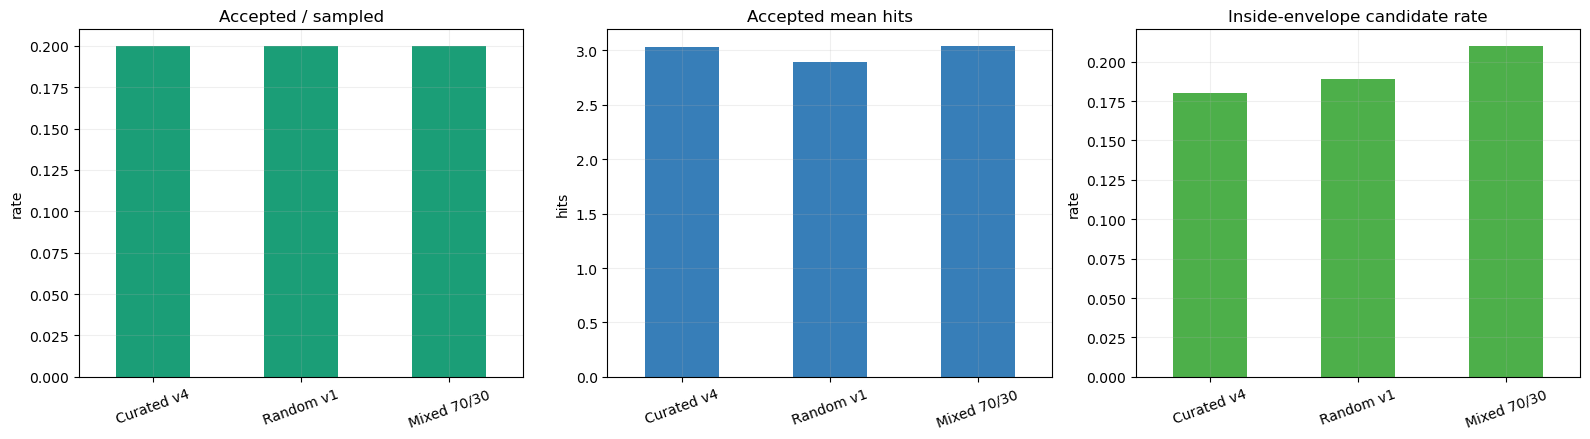

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), facecolor="white")

source_summary_df.plot.bar(x="source_label", y="accept_rate", ax=axes[0], color="#1b9e77", legend=False)
axes[0].set_title("Accepted / sampled")
axes[0].set_xlabel("")
axes[0].set_ylabel("rate")

source_summary_df.plot.bar(x="source_label", y="accepted_mean_hits", ax=axes[1], color="#377eb8", legend=False)
axes[1].set_title("Accepted mean hits")
axes[1].set_xlabel("")
axes[1].set_ylabel("hits")

source_summary_df.plot.bar(x="source_label", y="inside_candidate_rate", ax=axes[2], color="#4daf4a", legend=False)
axes[2].set_title("Inside-envelope candidate rate")
axes[2].set_xlabel("")
axes[2].set_ylabel("rate")

for ax in axes:
    ax.grid(alpha=0.2)
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


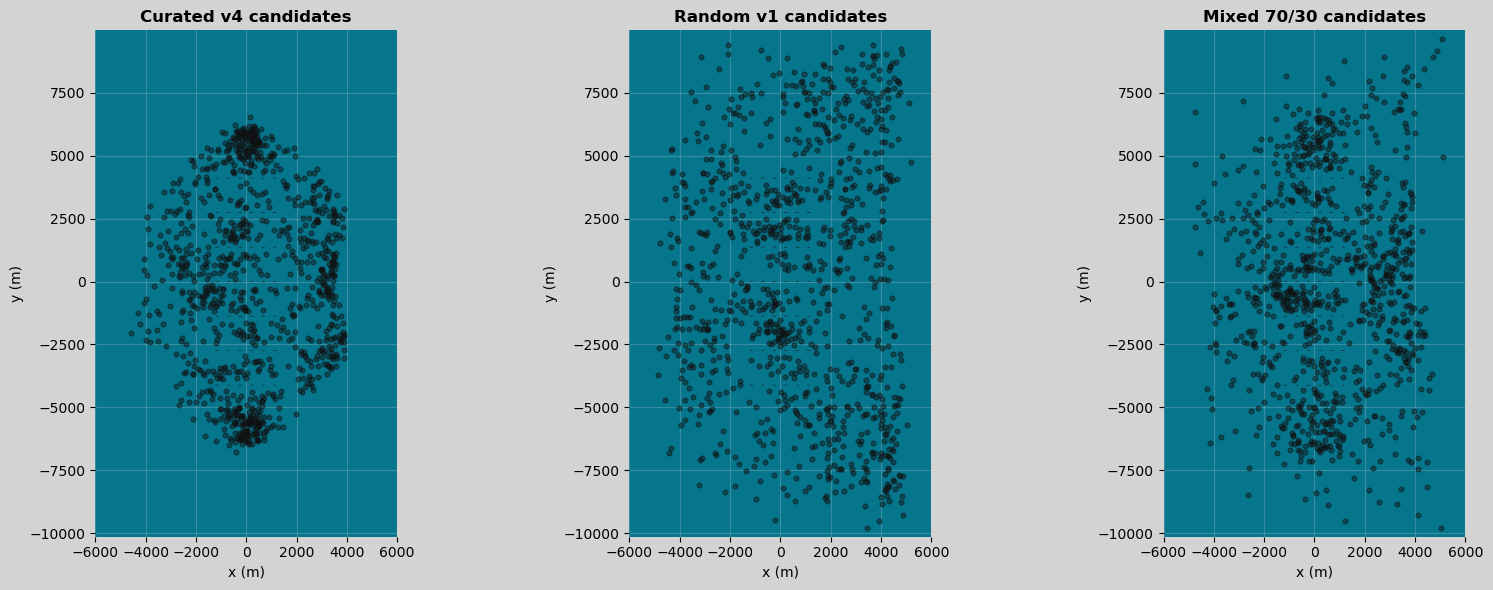

In [9]:
fig, axes = plt.subplots(1, len(source_payloads), figsize=(5.5 * len(source_payloads), 6), facecolor="lightgrey", squeeze=False)
axes = axes[0]
ships = get_convoy_layout_profile(CONVOY_PROFILE).build_ships()
all_points = candidate_df[["u_pos_x", "u_pos_y"]].to_numpy(dtype=float) if len(candidate_df) else None
shared_limits = combined_limits(ships, extra_points=all_points, pad=350.0)

for ax, payload in zip(axes, source_payloads):
    cfg = payload["config"]
    df = payload["df"]
    style_ax(ax, f"{cfg['label']} candidates")
    simple_ship_polygons(ax, ships)
    if len(df):
        xy = df[["u_pos_x", "u_pos_y"]].to_numpy(dtype=float)
        ax.scatter(xy[:, 0], xy[:, 1], c="#111111", s=12, alpha=0.45, zorder=2)
    apply_limits(ax, shared_limits, fixed_x_limits=FIXED_X_LIMITS)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
plt.tight_layout()
plt.show()


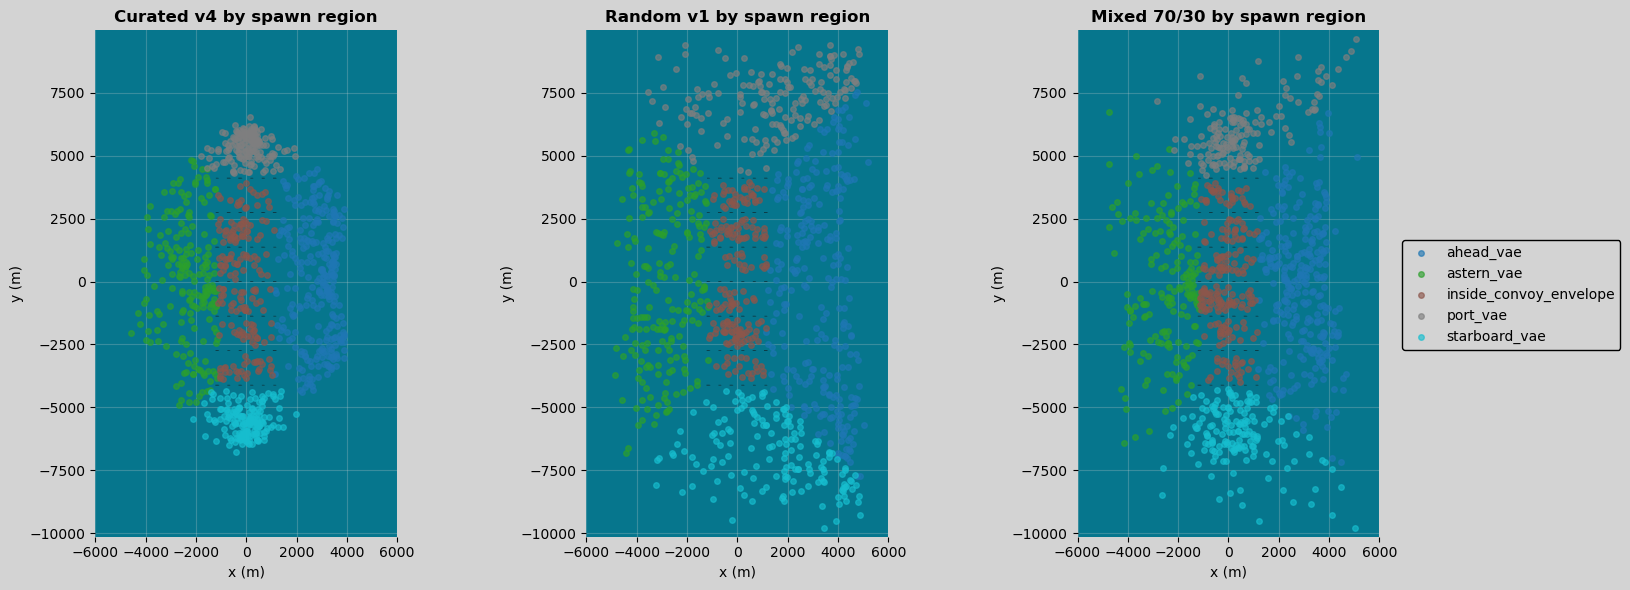

In [10]:
region_values = sorted(candidate_df["spawn_region"].dropna().unique().tolist())
colors = plt.cm.tab10(np.linspace(0, 1, max(len(region_values), 1)))
color_map = dict(zip(region_values, colors))
fig, axes = plt.subplots(1, len(source_payloads), figsize=(5.8 * len(source_payloads), 6), facecolor="lightgrey", squeeze=False)
axes = axes[0]

for ax, payload in zip(axes, source_payloads):
    cfg = payload["config"]
    df = payload["df"]
    style_ax(ax, f"{cfg['label']} by spawn region")
    simple_ship_polygons(ax, ships)
    for region in region_values:
        region_df = df.loc[df["spawn_region"] == region]
        if not len(region_df):
            continue
        xy = region_df[["u_pos_x", "u_pos_y"]].to_numpy(dtype=float)
        ax.scatter(xy[:, 0], xy[:, 1], s=16, alpha=0.65, color=color_map[region], label=region, zorder=2)
    apply_limits(ax, shared_limits, fixed_x_limits=FIXED_X_LIMITS)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")

handles, labels = axes[-1].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(.825, 0.5), frameon=True, facecolor="lightgrey", edgecolor="black", framealpha=1.0)
plt.tight_layout(rect=(0, 0, 0.88, 1))
plt.show()


## Optional Matched Monte Carlo Evaluation

This section is off by default. Turn `RUN_MONTE_CARLO_EVALUATION = True` in the config when the candidate-pool summaries look good.


In [11]:
eval_rows = []
if RUN_MONTE_CARLO_EVALUATION:
    objective_cfg = {} if OBJECTIVE_PRESET in {None, "", "none", "None"} else {"preset": str(OBJECTIVE_PRESET)}
    for payload in source_payloads:
        cfg = payload["config"]
        run_name = f"vae_source_compare_{cfg['source_id']}"
        print(f"Evaluating {cfg['source_id']} from {cfg['candidate_path']}")
        run_dir = evaluate_candidate_pool(
            candidate_path=PROJECT_ROOT / cfg["candidate_path"],
            project_root=PROJECT_ROOT,
            output_root=Path("results/runs"),
            run_name=run_name,
            convoy_profile=CONVOY_PROFILE,
            max_profiles=int(MAX_EVAL_PROFILES) if MAX_EVAL_PROFILES is not None else None,
            top_k=int(TOP_K),
            seeds=[int(seed) for seed in EVAL_SEEDS],
            n_trials_per_seed=int(N_TRIALS_PER_SEED),
            t_max=float(EVAL_T_MAX),
            max_hits_per_torpedo=1,
            objective_cfg=objective_cfg,
            noise_cfg={},
            environment_cfg={},
        )
        metrics = json.loads((run_dir / "metrics_summary.json").read_text(encoding="utf-8"))
        pool = dict(metrics.get("candidate_pool", {}))
        top = dict(metrics.get("top_k", {}))
        best = dict(metrics.get("best_candidate", {}) or {})
        eval_rows.append(
            {
                "source_id": cfg["source_id"],
                "source_label": cfg["label"],
                "run_dir": str(run_dir),
                "pool_profiles": pool.get("profiles"),
                "pool_expected_hits": pool.get("expected_hits"),
                "pool_expected_unique_ships_hit": pool.get("expected_unique_ships_hit"),
                "pool_expected_loss": pool.get("expected_loss"),
                "pool_value_lost": pool.get("value_lost"),
                "pool_p_hit_ge_1": pool.get("p_hit_ge_1"),
                "top_expected_hits": top.get("expected_hits"),
                "top_expected_unique_ships_hit": top.get("expected_unique_ships_hit"),
                "top_expected_loss": top.get("expected_loss"),
                "top_value_lost": top.get("value_lost"),
                "best_profile_id": best.get("profile_id"),
                "best_expected_hits": best.get("expected_hits"),
                "best_expected_loss": best.get("expected_loss"),
                "best_spawn_region": best.get("spawn_region"),
            }
        )
else:
    print("RUN_MONTE_CARLO_EVALUATION is False; skipping matched evaluation.")

eval_summary_df = pd.DataFrame(eval_rows)
if len(eval_summary_df):
    eval_summary_df.to_csv(OUTPUT_DIR / "monte_carlo_eval_source_summary.csv", index=False)
eval_summary_df


Evaluating curated_v4 from data/attack_profiles/vae_candidates/curated_v4_hit_candidates.jsonl
Evaluating random_v1 from data/attack_profiles/vae_candidates/random_v1_hit_candidates.jsonl
Evaluating mixed_70_30 from data/attack_profiles/vae_candidates/mixed_curated70_random30_hit_candidates.jsonl


,source_id,source_label,run_dir,pool_profiles,pool_expected_hits,pool_expected_unique_ships_hit,pool_expected_loss,pool_value_lost,pool_p_hit_ge_1,top_expected_hits,top_expected_unique_ships_hit,top_expected_loss,top_value_lost,best_profile_id,best_expected_hits,best_expected_loss,best_spawn_region
0,curated_v4,Curated v4,/Users/matthewplambeck/Desktop/Convoy Layout P...,100,2.922333,1.692667,3.673217,1.734617,0.978667,3.238667,2.474667,5.198333,2.570867,VAE000046,4.000000,6.426667,ahead_vae
1,random_v1,Random v1,/Users/matthewplambeck/Desktop/Convoy Layout P...,100,2.692333,1.808000,3.841950,1.857083,0.969333,3.156000,2.805333,5.745133,2.869667,VAE000018,3.733333,7.371667,starboard_vae
2,mixed_70_30,Mixed 70/30,/Users/matthewplambeck/Desktop/Convoy Layout P...,100,2.982000,1.817667,3.918017,1.867483,0.999667,3.406667,2.724000,5.669400,2.808867,VAE000124,3.966667,7.981667,starboard_vae


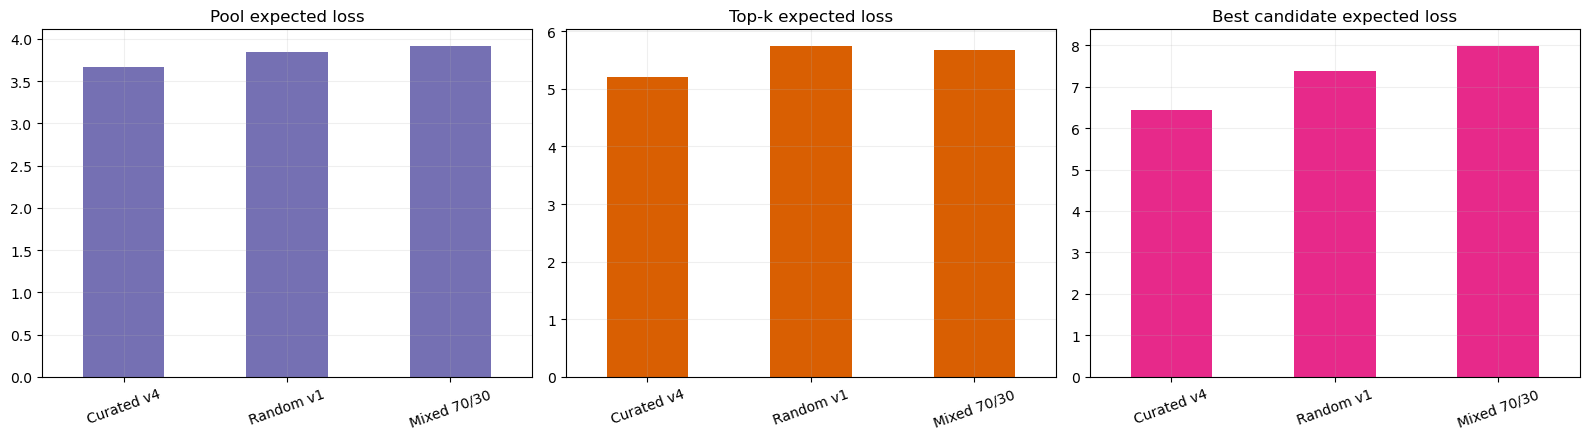

In [12]:
if len(eval_summary_df):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), facecolor="white")
    eval_summary_df.plot.bar(x="source_label", y="pool_expected_loss", ax=axes[0], color="#7570b3", legend=False)
    axes[0].set_title("Pool expected loss")
    eval_summary_df.plot.bar(x="source_label", y="top_expected_loss", ax=axes[1], color="#d95f02", legend=False)
    axes[1].set_title("Top-k expected loss")
    eval_summary_df.plot.bar(x="source_label", y="best_expected_loss", ax=axes[2], color="#e7298a", legend=False)
    axes[2].set_title("Best candidate expected loss")
    for ax in axes:
        ax.grid(alpha=0.2)
        ax.tick_params(axis="x", rotation=20)
        ax.set_xlabel("")
    plt.tight_layout()
    plt.show()


## Artifact Paths


In [13]:
artifact_summary = {
    "candidate_pool_summary_csv": str(OUTPUT_DIR / "candidate_pool_source_summary.csv"),
    "candidate_pool_records_flat_csv": str(OUTPUT_DIR / "candidate_pool_records_flat.csv"),
    "spawn_region_csv": str(OUTPUT_DIR / "candidate_pool_spawn_regions.csv"),
    "hit_count_csv": str(OUTPUT_DIR / "candidate_pool_hit_counts.csv"),
    "candidate_paths": {cfg["source_id"]: str(PROJECT_ROOT / cfg["candidate_path"]) for cfg in SOURCE_CONFIGS},
    "summary_paths": {cfg["source_id"]: str(PROJECT_ROOT / summary_path_for(cfg["candidate_path"])) for cfg in SOURCE_CONFIGS},
}
if len(eval_summary_df):
    artifact_summary["monte_carlo_eval_summary_csv"] = str(OUTPUT_DIR / "monte_carlo_eval_source_summary.csv")
artifact_summary


{'candidate_pool_summary_csv': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/vae_source_comparison/candidate_pool_source_summary.csv',
 'candidate_pool_records_flat_csv': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/vae_source_comparison/candidate_pool_records_flat.csv',
 'spawn_region_csv': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/vae_source_comparison/candidate_pool_spawn_regions.csv',
 'hit_count_csv': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/vae_source_comparison/candidate_pool_hit_counts.csv',
 'candidate_paths': {'curated_v4': '/Users/matthewplambeck/Desktop/Convoy Layout Project/data/attack_profiles/vae_candidates/curated_v4_hit_candidates.jsonl',
  'random_v1': '/Users/matthewplambeck/Desktop/Convoy Layout Project/data/attack_profiles/vae_candidates/random_v1_hit_candidates.jsonl',
  'mixed_70_30': '/Users/matthewplambeck/Desktop/Convoy Layout Project/data/attack_profiles/vae_candidat